# Full Equilibrium LOB for a Polymarket Digital Option
## Unified Trader MFG — Independent YES and NO Side HJB

---

**What this notebook computes.** The complete limit order book — ask side, bid side, and endogenous spread — for a binary contract on Polymarket.

- **YES ask**: LPs with $v < p$ sell YES at $a_{YES} \ge p$
- **NO ask** (= YES bid): LPs with $v_{NO} < 1-p$ sell NO at $a_{NO} \ge 1-p$, i.e. buy YES at $b = 1 - a_{NO}$

**Spread**: $s = a_{\text{best,YES}} + a_{\text{best,NO}} - 1 \ge 0$ (endogenous, from no-arbitrage via minting)

---
# Part I: Model

## §1. Contract
Binary option: $\text{Payoff}_{YES} = \mathbf{1}\{S_T \ge K\}$, YES + NO = \$1. The minting mechanism (deposit \$1 $\to$ 1 YES + 1 NO) implies selling NO at $a_{NO}$ = buying YES at $1 - a_{NO}$.

## §2. Traders
Each has $(v, r)$: valuation $v \sim \text{Beta}(\alpha_F, \beta_F)$ centered at $p$, discount rate $r \sim \text{Uniform}[r_{\min}, r_{\max}]$. Classification: $v \ge a$ $\to$ market buyer; $v \le b$ $\to$ market seller; in the spread $\to$ LP.

## §3. Two Independent Equilibria
YES side uses Beta $(\alpha_F, \beta_F)$; NO side uses Beta $(\beta_F, \alpha_F)$ (swapped, since $v_{NO} = 1 - v_{YES}$). Each runs the full Ma-Noh Bertrand fixed point independently.

## §4. HJB (Ma-Noh at each price level)
Depth $q$ follows a Poisson jump process. Replenishment at controlled rate $l \cdot \Psi(u)$, cost $(\kappa/2)l^2$. Execution at rate $\mu(a) \cdot \Theta(u)$, profit $(a(1-f)-v)\delta_b$. Policy iteration solves $AV = b$ (strictly diag. dominant, no $V_0$ pinning). Bertrand: $a^*(v,r) = \arg\max_a V_0(v,r,a)$.

## §5. Aggregation and Cumulative LOB
Density $d(a) = N \sum f(v_k)\Delta v \cdot g(r_j)\Delta r \cdot \bar{d}_{k,j} \cdot K_\sigma(a - a^*_{k,j})$. Cumulative: $\mathcal{D}_{cum}(a) = \int_a^{a_{\max}} d(s)\,ds$.

---
# Part II: Implementation

In [8]:
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §6. Ma-Noh Functions

In [9]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, ds, db):
    q = np.asarray(q); N = q.size
    jp = np.empty(N, dtype=int); jm = np.empty(N, dtype=int)
    for i in range(N):
        jp[i] = int(np.argmin(np.abs(q - (q[i] + ds))))
        jm[i] = int(np.argmin(np.abs(q - max(q[i] - db, 0.0))))
    return jp, jm

def solve_hjb(q, u, jp, jm, rho, kappa, l_bar, psi, theta, margin, db,
              mu_exec, max_iter=60, tol=1e-10):
    N = len(q); Psi = 1+psi*u; Theta = 1+theta*(1-u)
    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        ls = l*Psi; lb = mu_exec*Theta
        pi = margin*lb*db*(q > 0).astype(float)
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i,i] = rho + ls[i] + lb[i]
            A[i,jp[i]] -= ls[i]; A[i,jm[i]] -= lb[i]
            b[i] = pi[i] - 0.5*kappa*l[i]**2
        try: Vn = np.linalg.solve(A, b)
        except: break
        ln = proj_0_lbar((Psi/kappa)*(Vn[jp]-Vn), l_bar)
        if np.max(np.abs(ln-l)) < tol: V,l = Vn,ln; break
        V,l = Vn,ln
    return V, l

def stat_dist(jp, jm, lp, lm):
    N = len(lp); rates = np.array(lp)+np.array(lm)
    bL = max(np.max(rates), 1e-12); P = np.zeros((N,N))
    for i in range(N):
        if rates[i] > 0:
            P[i,jp[i]] += lp[i]/bL; P[i,jm[i]] += lm[i]/bL
            P[i,i] += 1-rates[i]/bL
        else: P[i,i] = 1
    m = np.ones(N)/N; PT = P.T
    for _ in range(80000):
        mn = PT@m; s = mn.sum()
        if s <= 0: break
        mn /= s
        if np.max(np.abs(mn-m)) < 1e-14: m = mn; break
        m = mn
    return m

def quant_upd(u, q, m):
    M = np.cumsum(m); M = np.clip(M, 0, 1); Me = M.copy()
    for i in range(1, len(Me)):
        if Me[i] <= Me[i-1]: Me[i] = Me[i-1]+1e-12
    return np.interp(u, np.clip(Me, 0, 1), q, left=q[0], right=q[-1])

## §7. Parameters and One-Side Solver

In [10]:
# ================================================================
p_mid   = 0.65
fee     = 0.02
alpha_F = 6.5; beta_F = 3.5  # Beta mean = alpha/(alpha+beta) = 0.65 = p
lam_arr = 10.0
delta_s = 1.0; delta_b_size = 1.0
kappa   = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_total = 100.0; r_min = 0.05; r_max = 2.0

# Grids
N_v = 5; N_r = 6; N_a = 12; N_q = 35; q_max = 20.0
r_grid = np.linspace(r_min, r_max, N_r)
omega = 0.10; outer_max = 30; cesaro_start = 18; sigma_smooth = 0.020


# ================================================================
# Generic one-side solver
# ================================================================
def solve_one_side(p_fund, alpha_beta, beta_beta, side_label,
                    N_v=N_v, N_r=N_r, N_a=N_a):
    """
    Solve the Bertrand-MaNoh equilibrium for one side of the book.
    
    Args:
        p_fund: fundamental for this contract (p for YES, 1-p for NO)
        alpha_beta, beta_beta: Beta distribution params for this side
        side_label: 'YES' or 'NO' (for printing)
    
    Returns:
        a_grid_side: ask prices for this side
        D_final: equilibrium density d(a)
        D_cum: cumulative depth
        a_star_2d: optimal asks (N_v x N_r)
        d_bar_2d: mean depths (N_v x N_r)
        v_grid_side: LP valuations
    """
    # LP valuations: v < p_fund (bearish LPs who sell this contract)
    v_max_lp = p_fund * (1 - fee) - 0.01
    if v_max_lp <= 0.02:
        v_max_lp = 0.02
    v_grid_s = np.linspace(0.05, max(v_max_lp, 0.06), N_v)
    
    # Ask grid: a >= p_fund (no-arbitrage)
    a_lo = p_fund + 0.005
    a_hi = min(0.98, 1.0 - fee)
    if a_lo >= a_hi:
        a_lo = a_hi - 0.05
    a_grid_s = np.linspace(a_lo, a_hi, N_a)
    
    # Order flow: phi(a) = lam * [1 - F_Beta(a; alpha, beta)]
    def phi_s(a):
        return lam_arr * (1.0 - beta_dist.cdf(a, alpha_beta, beta_beta))
    
    def margin_s(a, v):
        return a * (1 - fee) - v
    
    def solve_at(a_p, v_lp, rho, mu, ni=5):
        mg = margin_s(a_p, v_lp)
        if mg <= 0.001: return 0.0, 0.0
        u = rank_grid(N_q); q = np.linspace(0, q_max, N_q)
        for _ in range(ni):
            jp, jm = destination_indices(q, delta_s, delta_b_size)
            V, l = solve_hjb(q, u, jp, jm, rho=rho, kappa=kappa, l_bar=l_bar,
                              psi=psi, theta=theta, margin=mg, db=delta_b_size,
                              mu_exec=mu)
            Psi = 1+psi*u; Theta = 1+theta*(1-u)
            m = stat_dist(jp, jm, l*Psi, mu*np.ones_like(q)*Theta)
            qt = quant_upd(u, q, m)
            q = np.maximum(np.sort((1-0.15)*q + 0.15*qt), 0)
        return float(V[0]), float(np.dot(m, q))
    
    # Run equilibrium
    print(f"\n--- {side_label} side (p={p_fund:.2f}) ---")
    print(f"  Beta({alpha_beta}, {beta_beta}), asks: [{a_grid_s[0]:.3f}, {a_grid_s[-1]:.3f}]")
    print(f"  LP valuations: [{v_grid_s[0]:.3f}, {v_grid_s[-1]:.3f}]")
    
    dv = v_grid_s[1]-v_grid_s[0] if N_v > 1 else 1.0
    dr = r_grid[1]-r_grid[0] if N_r > 1 else 1.0
    
    D_a = np.ones(N_a) * 2.0
    D_ces = np.zeros(N_a); ces_n = 0
    a_star_2d = np.zeros((N_v, N_r))
    d_bar_2d = np.zeros((N_v, N_r))
    t0 = time.time()
    
    for oit in range(outer_max):
        mu_a = phi_s(a_grid_s) / np.maximum(D_a, 0.01)
        
        for kv in range(N_v):
            for kr in range(N_r):
                best = -np.inf; bj = 0; bdb = 0
                for j in range(N_a):
                    if margin_s(a_grid_s[j], v_grid_s[kv]) <= 0.001: continue
                    ni = 3 if oit < 10 else 5
                    V0j, dbj = solve_at(a_grid_s[j], v_grid_s[kv], r_grid[kr], mu_a[j], ni)
                    if V0j > best: best = V0j; bj = j; bdb = dbj
                a_star_2d[kv, kr] = a_grid_s[bj]
                d_bar_2d[kv, kr] = bdb
        
        D_new = np.zeros(N_a); step = a_grid_s[1]-a_grid_s[0]
        for kv in range(N_v):
            for kr in range(N_r):
                fv = beta_dist.pdf(v_grid_s[kv], alpha_beta, beta_beta)
                w = N_total * fv * dv / (r_max - r_min) * dr * d_bar_2d[kv, kr]
                kern = np.exp(-0.5*((a_grid_s - a_star_2d[kv, kr])/sigma_smooth)**2)
                kern /= (np.sum(kern)*step + 1e-20)
                D_new += w * kern * step
        
        D_new = np.maximum(D_new, 0.005)
        D_a = (1-omega)*D_a + omega*D_new
        if oit >= cesaro_start:
            ces_n += 1; D_ces += (D_a - D_ces) / ces_n
        
        if (oit+1) % 10 == 0 or oit == 0:
            mid = N_v // 2
            print(f"  iter {oit+1:3d}: a* in [{a_star_2d[mid,:].min():.3f}, "
                  f"{a_star_2d[mid,:].max():.3f}], D_max={D_a.max():.2f} "
                  f"[{time.time()-t0:.0f}s]")
    
    D_final = D_ces if ces_n > 0 else D_a
    
    # Cumulative
    D_cum = np.zeros(N_a)
    for i in range(N_a):
        if len(a_grid_s[i:]) > 1:
            D_cum[i] = np.trapz(D_final[i:], a_grid_s[i:])
    
    print(f"  Done in {time.time()-t0:.0f}s. Best ask = {a_grid_s[0]:.3f}, "
          f"D_max = {D_final.max():.3f}")
    
    return a_grid_s, D_final, D_cum, a_star_2d, d_bar_2d, v_grid_s

## §8. Run Both Sides

In [11]:
print("Full LOB: YES Ask + NO Ask (= YES Bid)")
print("="*60)
print(f"p = {p_mid}, fee = {fee}")
print(f"YES valuations: Beta({alpha_F}, {beta_F})")
print(f"NO valuations:  Beta({beta_F}, {alpha_F})")

# YES ask side
a_yes, d_yes, dc_yes, as_yes, db_yes, v_yes = solve_one_side(
    p_mid, alpha_F, beta_F, 'YES')

# NO ask side (= YES bid side)
# NO fundamental = 1 - p
# NO valuations: if v_YES ~ Beta(alpha, beta), then v_NO = 1-v_YES ~ Beta(beta, alpha)
p_no = 1.0 - p_mid
a_no, d_no, dc_no, as_no, db_no, v_no = solve_one_side(
    p_no, beta_F, alpha_F, 'NO')

# ================================================================
# Convert NO ask → YES bid
# ================================================================
# YES bid price b = 1 - a_NO
b_yes = 1.0 - a_no[::-1]       # reverse so b is increasing
d_bid = d_no[::-1]               # density at each bid price
dc_bid = np.zeros(len(b_yes))   # cumulative bid = integral from b_min to b
for i in range(len(b_yes)):
    if i > 0:
        dc_bid[i] = np.trapz(d_bid[:i+1], b_yes[:i+1])

# Spread
a_best_yes = a_yes[0]           # lowest YES ask
a_best_no = a_no[0]             # lowest NO ask
b_best_yes = 1.0 - a_best_no   # highest YES bid
spread = a_best_yes + a_best_no - 1.0

print(f"\n{'='*60}")
print(f"EQUILIBRIUM RESULTS")
print(f"{'='*60}")
print(f"Best YES ask  = {a_best_yes:.4f}")
print(f"Best NO ask   = {a_best_no:.4f}")
print(f"Best YES bid  = {b_best_yes:.4f}")
print(f"Spread        = {spread:.4f}")
print(f"Mid-price     = {p_mid:.4f}")
print(f"No-arbitrage  = {spread >= -1e-10}")

Full LOB: YES Ask + NO Ask (= YES Bid)
p = 0.65, fee = 0.02
YES valuations: Beta(6.5, 3.5)
NO valuations:  Beta(3.5, 6.5)

--- YES side (p=0.65) ---
  Beta(6.5, 3.5), asks: [0.655, 0.980]
  LP valuations: [0.050, 0.627]
  iter   1: a* in [0.714, 0.803], D_max=2.50 [3s]
  iter  10: a* in [0.685, 0.773], D_max=3.45 [26s]
  iter  20: a* in [0.655, 0.773], D_max=3.71 [67s]
  iter  30: a* in [0.655, 0.773], D_max=4.13 [107s]
  Done in 107s. Best ask = 0.655, D_max = 3.778

--- NO side (p=0.35) ---
  Beta(3.5, 6.5), asks: [0.355, 0.980]
  LP valuations: [0.050, 0.333]
  iter   1: a* in [0.469, 0.525], D_max=2.95 [3s]
  iter  10: a* in [0.355, 0.469], D_max=4.71 [32s]
  iter  20: a* in [0.355, 0.469], D_max=4.97 [82s]
  iter  30: a* in [0.355, 0.469], D_max=4.99 [131s]
  Done in 131s. Best ask = 0.355, D_max = 5.154

EQUILIBRIUM RESULTS
Best YES ask  = 0.6550
Best NO ask   = 0.3550
Best YES bid  = 0.6450
Spread        = 0.0100
Mid-price     = 0.6500
No-arbitrage  = True


---
# Part III: Results

## §9. Full LOB Visualization


FINAL SUMMARY
YES ask: a* in [0.655, 0.832], D_max=3.778
NO ask:  a* in [0.355, 0.753], D_max=5.154
Spread = 0.0100
Asymmetric: YES depth = 0.643, Bid depth = 1.340


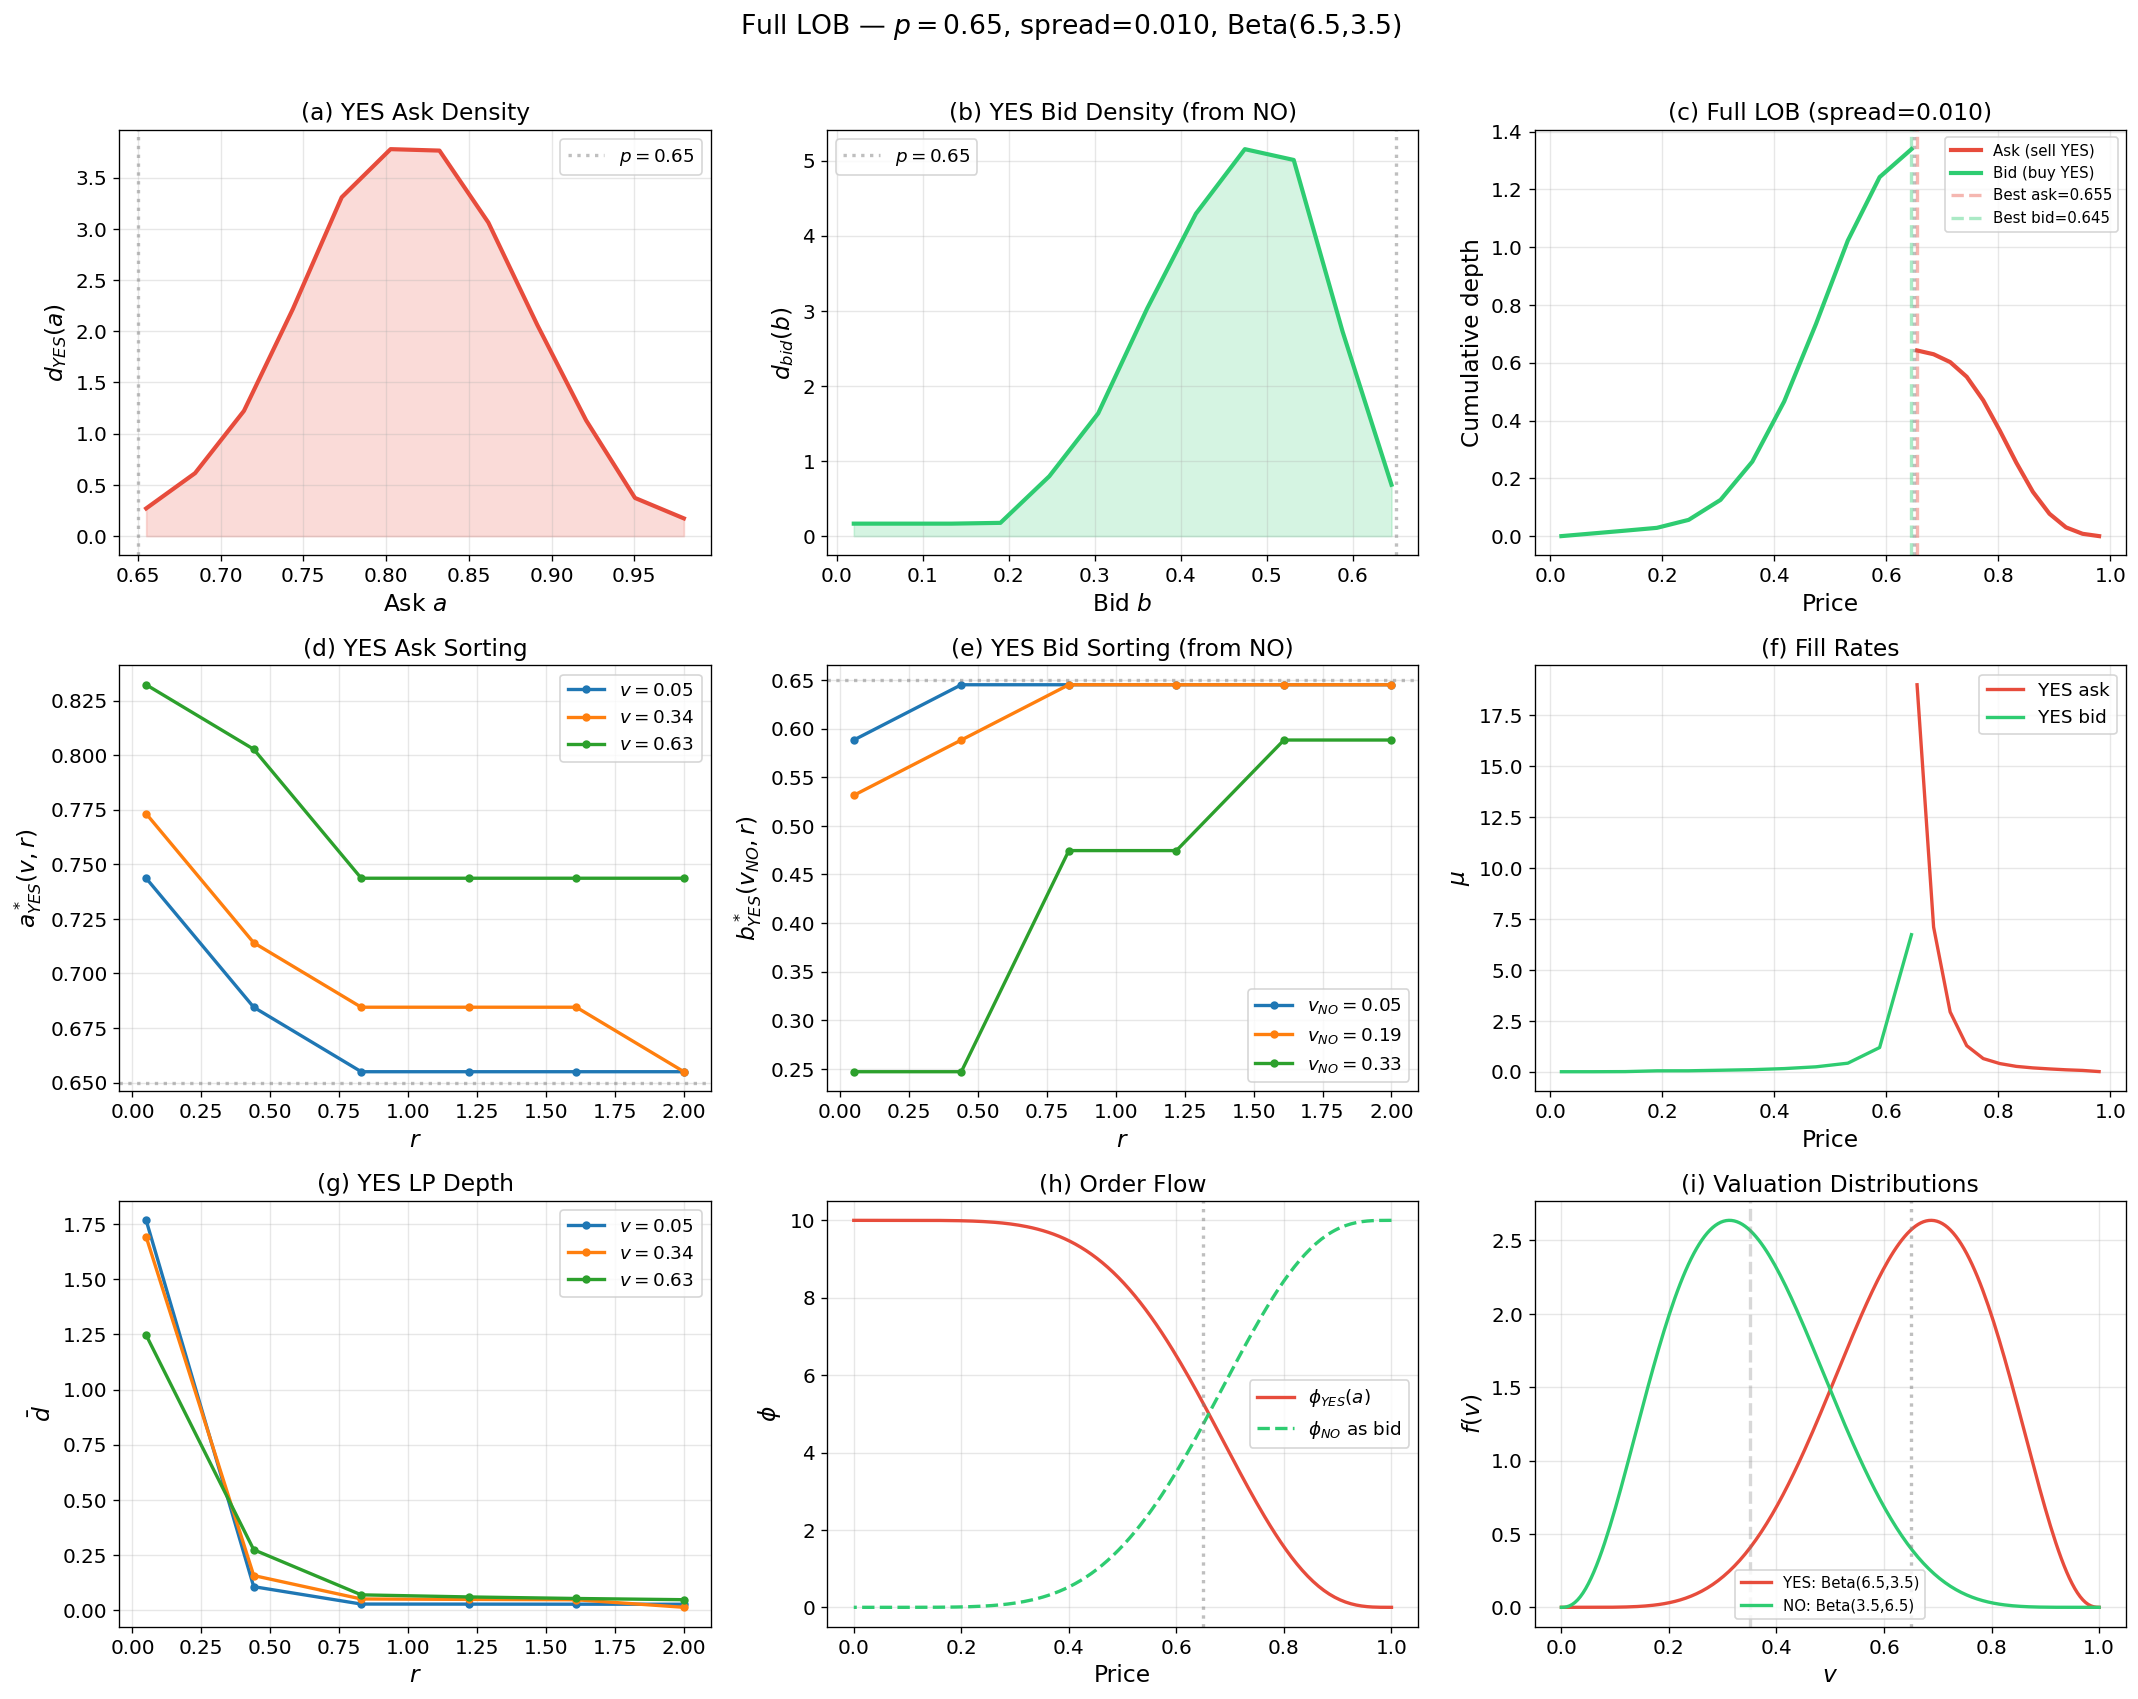

In [12]:

# Value landscape for YES side
mu_yes_final = np.where(dc_yes > 0.001, 
                         lam_arr*(1-beta_dist.cdf(a_yes, alpha_F, beta_F))/np.maximum(d_yes, 0.005),
                         1.0)

fig = plt.figure(figsize=(18, 14))

# (a) YES ask density
ax = fig.add_subplot(3, 3, 1)
ax.plot(a_yes, d_yes, color='#e74c3c', lw=2.5)
ax.fill_between(a_yes, 0, d_yes, alpha=0.2, color='#e74c3c')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5, label=f'$p={p_mid}$')
ax.set_xlabel('Ask $a$'); ax.set_ylabel('$d_{YES}(a)$')
ax.set_title('(a) YES Ask Density'); ax.legend(); ax.grid(True, alpha=0.3)

# (b) YES bid density (from NO ask)
ax = fig.add_subplot(3, 3, 2)
ax.plot(b_yes, d_bid, color='#2ecc71', lw=2.5)
ax.fill_between(b_yes, 0, d_bid, alpha=0.2, color='#2ecc71')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5, label=f'$p={p_mid}$')
ax.set_xlabel('Bid $b$'); ax.set_ylabel('$d_{bid}(b)$')
ax.set_title('(b) YES Bid Density (from NO)'); ax.legend(); ax.grid(True, alpha=0.3)

# (c) Full LOB cumulative
ax = fig.add_subplot(3, 3, 3)
ax.plot(a_yes, dc_yes, color='#e74c3c', lw=2.5, label='Ask (sell YES)')
ax.plot(b_yes, dc_bid, color='#2ecc71', lw=2.5, label='Bid (buy YES)')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.axvline(a_best_yes, color='#e74c3c', ls='--', alpha=0.4, label=f'Best ask={a_best_yes:.3f}')
ax.axvline(b_best_yes, color='#2ecc71', ls='--', alpha=0.4, label=f'Best bid={b_best_yes:.3f}')
ax.set_xlabel('Price'); ax.set_ylabel('Cumulative depth')
ax.set_title(f'(c) Full LOB (spread={spread:.3f})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (d) YES Bertrand sorting
ax = fig.add_subplot(3, 3, 4)
for kv in [0, N_v//2, N_v-1]:
    ax.plot(r_grid, as_yes[kv, :], 'o-', ms=4, label=f'$v={v_yes[kv]:.2f}$')
ax.axhline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('$r$'); ax.set_ylabel('$a^*_{YES}(v, r)$')
ax.set_title('(d) YES Ask Sorting'); ax.legend(); ax.grid(True, alpha=0.3)

# (e) NO Bertrand sorting
ax = fig.add_subplot(3, 3, 5)
for kv in [0, N_v//2, N_v-1]:
    # Convert NO ask to YES bid
    ax.plot(r_grid, 1.0 - as_no[kv, :], 'o-', ms=4, label=f'$v_{{NO}}={v_no[kv]:.2f}$')
ax.axhline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('$r$'); ax.set_ylabel('$b^*_{YES}(v_{NO}, r)$')
ax.set_title('(e) YES Bid Sorting (from NO)'); ax.legend(); ax.grid(True, alpha=0.3)

# (f) Fill rates both sides
ax = fig.add_subplot(3, 3, 6)
phi_yes_vals = lam_arr * (1 - beta_dist.cdf(a_yes, alpha_F, beta_F))
mu_yes_vals = phi_yes_vals / np.maximum(d_yes, 0.005)
phi_no_vals = lam_arr * (1 - beta_dist.cdf(a_no, beta_F, alpha_F))
mu_no_vals = phi_no_vals / np.maximum(d_no, 0.005)
ax.plot(a_yes, mu_yes_vals, color='#e74c3c', lw=2, label='YES ask')
ax.plot(b_yes, mu_no_vals[::-1], color='#2ecc71', lw=2, label='YES bid')
ax.set_xlabel('Price'); ax.set_ylabel(r'$\mu$')
ax.set_title('(f) Fill Rates'); ax.legend(); ax.grid(True, alpha=0.3)

# (g) Depth by type (YES)
ax = fig.add_subplot(3, 3, 7)
for kv in [0, N_v//2, N_v-1]:
    ax.plot(r_grid, db_yes[kv, :], 'o-', ms=4, label=f'$v={v_yes[kv]:.2f}$')
ax.set_xlabel('$r$'); ax.set_ylabel(r'$\bar{d}$')
ax.set_title('(g) YES LP Depth'); ax.legend(); ax.grid(True, alpha=0.3)

# (h) Order flow both sides
ax = fig.add_subplot(3, 3, 8)
a_fine = np.linspace(0, 1, 200)
phi_yes_fine = lam_arr * (1 - beta_dist.cdf(a_fine, alpha_F, beta_F))
phi_no_fine = lam_arr * (1 - beta_dist.cdf(a_fine, beta_F, alpha_F))
ax.plot(a_fine, phi_yes_fine, color='#e74c3c', lw=2, label=r'$\phi_{YES}(a)$')
ax.plot(1-a_fine, phi_no_fine, color='#2ecc71', lw=2, ls='--', label=r'$\phi_{NO}$ as bid')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Price'); ax.set_ylabel(r'$\phi$')
ax.set_title('(h) Order Flow'); ax.legend(); ax.grid(True, alpha=0.3)

# (i) Valuation densities
ax = fig.add_subplot(3, 3, 9)
ax.plot(a_fine, beta_dist.pdf(a_fine, alpha_F, beta_F), color='#e74c3c', lw=2, label=f'YES: Beta({alpha_F},{beta_F})')
ax.plot(a_fine, beta_dist.pdf(a_fine, beta_F, alpha_F), color='#2ecc71', lw=2, label=f'NO: Beta({beta_F},{alpha_F})')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.axvline(1-p_mid, color='gray', ls='--', alpha=0.3)
ax.set_xlabel('$v$'); ax.set_ylabel('$f(v)$')
ax.set_title('(i) Valuation Distributions'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(f'Full LOB — $p={p_mid}$, spread={spread:.3f}, Beta({alpha_F},{beta_F})',
             fontsize=16, y=1.01)
plt.tight_layout()

# Final summary
print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
print(f"YES ask: a* in [{as_yes.min():.3f}, {as_yes.max():.3f}], D_max={d_yes.max():.3f}")
print(f"NO ask:  a* in [{as_no.min():.3f}, {as_no.max():.3f}], D_max={d_no.max():.3f}")
print(f"Spread = {spread:.4f}")
print(f"Asymmetric: YES depth = {dc_yes[0]:.3f}, Bid depth = {dc_bid[-1]:.3f}")

## §10. Interpretation

**Panel (c): Full LOB.** Ask and bid sides computed independently. The asymmetry is endogenous: Beta $(\alpha_F, \beta_F)$ and Beta $(\beta_F, \alpha_F)$ have different tail shapes, producing different LP populations on each side.

**Panels (d)–(e): Two-sided sorting.** YES: $a^*(v,r)$ decreasing in $r$ (patient sellers post far from $p$). Bid: $b^*(v_{NO}, r) = 1 - a^*_{NO}$ increasing toward $p$ for patient NO sellers.

**Spread.** $s = a_{\text{best,YES}} + a_{\text{best,NO}} - 1$. Both best prices are endogenous from their respective HJBs. No-arbitrage is guaranteed by the minting mechanism.

| | YES Ask | YES Bid (from NO) |
|---|---|---|
| Fundamental | $p$ | $1-p$ |
| Valuations | Beta $(\alpha_F, \beta_F)$ | Beta $(\beta_F, \alpha_F)$ |
| LP condition | $v < p$ | $v_{NO} < 1-p$ |
| Margin | $a(1-f) - v$ | $a_{NO}(1-f) - v_{NO}$ |

## §11. Next Steps
1. Calibrate Beta $(\alpha_F, \beta_F)$ from Polymarket order flow
2. Run across contracts with different $p$ values
3. Compare predicted vs actual LOB shapes
4. Pareto $G(r)$ for discount rates
5. Price dynamics and informational efficiency